# Lab 24: Causal ML — Double Machine Learning (Diagnostic Lab)
## ECON 5200: Causal Machine Learning & Applied Analytics
### Diagnosis-First Lab | 40 min Core + 20 min Extension

---

**Format:** This lab contains **deliberately flawed code**. Your job:
1. Run the code
2. Identify what is wrong (you are told how many bugs, not where)
3. Fix the issue
4. Verify on a known DGP
5. Extend with Causal Forests

**Learning Objectives:**
- Implement manual 2-fold cross-fitting from scratch and debug common mistakes
- Understand why cross-fitting, treatment residualization, and the IV-style formula are each essential
- Estimate the ATE of 401(k) eligibility using the DoubleML package
- Assess robustness with sensitivity analysis
- Fit a Causal Forest (EconML) to estimate individual-level CATEs
- Compare subgroup DML to Causal Forest heterogeneity detection

**Verification checkpoints** are provided so you can confirm you found the right errors.

**Time estimate:** ~60 minutes

---

In [1]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Install required packages and import libraries
# -----------------------------------------------------------
!pip install -q doubleml econml

from doubleml import DoubleMLData, DoubleMLPLR
from doubleml.datasets import fetch_401K
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LassoCV
from sklearn.model_selection import KFold
from econml.dml import CausalForestDML
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

# Load 401(k) data
data = fetch_401K(return_type='DataFrame')

print(f'Dataset shape: {data.shape}')
print(f'Columns: {list(data.columns)}')
print('Libraries loaded. Ready to diagnose.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 603.5/603.5 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 43.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.7/14.7 MB 42.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 21.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 151.9/151.9 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 230.3/230.3 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.2/55.2 kB 1.8 MB/s eta 0:00:00
Dataset shape: (9915, 14)
Columns: ['nifa', 'net_tfa', 'tw', 'age', 'inc', 'fsize', 'educ', 'db', 'marr', 'twoearn', 'e401', 'p401', 'pira', 'hown']
Libraries loaded. Ready to diagnose.


---

## Part A: Manual Cross-Fitting — DIAGNOSE

The code below attempts to implement the DML algorithm manually using
2-fold cross-fitting. It has **three deliberate bugs**:

1. **Bug 1 (Data Leakage):** Uses the same data for training AND residual computation — violates cross-fitting
2. **Bug 2 (Missing Residualization):** Only residualizes the outcome $Y$, not the treatment $D$
3. **Bug 3 (Wrong Formula):** Uses `np.mean` of residual products instead of the correct IV-style formula for $\hat{\theta}$

**Your task:** Find all three bugs, explain why each matters, and fix them.

**The correct DML formula:**

$$\hat{\theta} = \frac{\sum_i \tilde{D}_i \tilde{Y}_i}{\sum_i \tilde{D}_i D_i}$$

where $\tilde{Y}_i = Y_i - \hat{\ell}(X_i)$ and $\tilde{D}_i = D_i - \hat{m}(X_i)$ are
the residuals from cross-fitted nuisance models.

In [2]:
# -----------------------------------------------------------
# DIAGNOSE: This code has 3 bugs. Find and fix them all.
# Manual 2-fold cross-fitting DML
# -----------------------------------------------------------

# Generate simulated data with known ATE for verification
np.random.seed(42)
n = 5000
p = 100
TRUE_ATE = 5.0

X_sim = np.random.normal(0, 1, size=(n, p))
propensity = 1 / (1 + np.exp(-(0.5 * X_sim[:, 0] + 0.3 * X_sim[:, 1] + 0.2 * X_sim[:, 2])))
D_sim = np.random.binomial(1, propensity)
Y_sim = (TRUE_ATE * D_sim
         + 2.0 * X_sim[:, 0] + 1.5 * X_sim[:, 1] + 1.0 * X_sim[:, 2]
         + 0.5 * X_sim[:, 3] + 0.3 * X_sim[:, 4]
         + np.random.normal(0, 1, n))


def broken_dml(Y, D, X, random_state=42):
    """
    BROKEN manual DML implementation with 3 bugs.

    Bug 1: Uses same fold for training and prediction (no cross-fitting)
    Bug 2: Only residualizes Y, not D
    Bug 3: Uses np.mean(V_tilde * Y_tilde) instead of sum(V_tilde * Y_tilde) / sum(V_tilde * D)
    """
    n = len(Y)
    kf = KFold(n_splits=2, shuffle=True, random_state=random_state)

    Y_tilde = np.zeros(n)  # outcome residuals
    V_tilde = np.zeros(n)  # treatment residuals (but Bug 2 skips this)

    for train_idx, test_idx in kf.split(X):
        # --- Outcome model: Y ~ X ---
        ml_l = RandomForestRegressor(n_estimators=200, max_depth=5, random_state=42)

        # BUG 1: Training and predicting on the SAME fold (train_idx)
        # Should train on train_idx, predict on test_idx
        ml_l.fit(X[train_idx], Y[train_idx])
        Y_hat = ml_l.predict(X[train_idx])       # <-- BUG: should be X[test_idx]
        Y_tilde[train_idx] = Y[train_idx] - Y_hat  # <-- BUG: should index test_idx

        # BUG 2: Missing treatment residualization entirely
        # Should fit ml_m on D ~ X and compute D_tilde = D - D_hat
        # Instead, just uses raw D as V_tilde
        V_tilde[train_idx] = D[train_idx]  # <-- BUG: should be D[test_idx] - D_hat[test_idx]

    # BUG 3: Wrong formula — uses np.mean instead of IV-style ratio
    # Correct: theta = sum(V_tilde * Y_tilde) / sum(V_tilde * D)
    theta = np.mean(V_tilde * Y_tilde)  # <-- BUG: wrong formula

    return theta


# Run the broken version
broken_ate = broken_dml(Y_sim, D_sim, X_sim)

print('=== BROKEN DML Results ===')
print(f'True ATE:    {TRUE_ATE:.2f}')
print(f'Broken ATE:  {broken_ate:.2f}')
print(f'Bias:        {broken_ate - TRUE_ATE:+.2f}')
print()
print('This estimate is far from the true ATE of 5.0.')
print('Find and fix the 3 bugs to recover the correct estimate.')

=== BROKEN DML Results ===
True ATE:    5.00
Broken ATE:  1.09
Bias:        -3.91

This estimate is far from the true ATE of 5.0.
Find and fix the 3 bugs to recover the correct estimate.


In [4]:
# -----------------------------------------------------------
# YOUR TASK — Fix the broken DML implementation
# After fixing, verify on the simulated DGP (TRUE_ATE = 5.0)
# -----------------------------------------------------------
from sklearn.base import clone

def fixed_dml(Y, D, X, random_state=42):
    """
    FIXED manual DML implementation.

    Fix 1: Cross-fit — train on one fold, predict on the other (no data leakage)
    Fix 2: Residualize BOTH Y and D (FWL theorem requires double residualization)
    Fix 3: Use IV-style formula: theta = sum(D_tilde * Y_tilde) / sum(D_tilde * D)
    """
    n = len(Y)
    kf = KFold(n_splits=2, shuffle=True, random_state=random_state)

    # Initialize residual arrays
    Y_tilde = np.zeros(n)
    D_tilde = np.zeros(n)

    # Base estimators (we'll clone these for each fold to avoid contamination)
    ml_l_base = RandomForestRegressor(n_estimators=200, max_depth=5, random_state=42)
    ml_m_base = RandomForestRegressor(n_estimators=200, max_depth=5, random_state=42)

    for train_idx, test_idx in kf.split(X):
        # Clone to get fresh, untrained estimators for this fold
        ml_l = clone(ml_l_base)
        ml_m = clone(ml_m_base)

        # --- Outcome nuisance model: E[Y | X] ---
        # FIX BUG 1: train on train_idx, predict on test_idx (cross-fitting)
        ml_l.fit(X[train_idx], Y[train_idx])
        Y_hat = ml_l.predict(X[test_idx])
        Y_tilde[test_idx] = Y[test_idx] - Y_hat

        # --- Treatment nuisance model: E[D | X] ---
        # FIX BUG 2: residualize D as well (not just Y)
        ml_m.fit(X[train_idx], D[train_idx])
        D_hat = ml_m.predict(X[test_idx])
        D_tilde[test_idx] = D[test_idx] - D_hat

    # FIX BUG 3: IV-style formula (not np.mean)
    # theta = sum(D_tilde * Y_tilde) / sum(D_tilde * D)
    theta = np.sum(D_tilde * Y_tilde) / np.sum(D_tilde * D)

    return theta


# Verify on simulated data
fixed_ate = fixed_dml(Y_sim, D_sim, X_sim)

print('=== FIXED DML Results ===')
print(f'True ATE:    {TRUE_ATE:.2f}')
print(f'Fixed ATE:   {fixed_ate:.2f}')
print(f'Bias:        {fixed_ate - TRUE_ATE:+.2f}')
print()

if abs(fixed_ate - TRUE_ATE) < 1.0:
    print('PASS — Fixed ATE is within 1.0 of the true value.')
else:
    print('FAIL — Fixed ATE is still far from 5.0. Check your fixes.')

=== FIXED DML Results ===
True ATE:    5.00
Fixed ATE:   5.17
Bias:        +0.17

PASS — Fixed ATE is within 1.0 of the true value.


---

## Part B: Package-Based DML

Now use the `doubleml` package to estimate the 401(k) ATE properly.
Less scaffolding than the 3916 lab — you should know the API from Part A.

In [6]:
# -----------------------------------------------------------
# YOUR TASK — Estimate the 401(k) ATE with DoubleML
#
# ACADEMIC NOTE: We estimate TWO specifications.
# Spec 1: Clean pre-treatment covariates only (Chernozhukov & Hansen 2004)
# Spec 2: All available covariates (lab default — includes potential bad controls)
#
# The divergence between these two is itself an important finding.
# -----------------------------------------------------------

# Step 1: Define variable sets
y_col = 'net_tfa'
d_col = 'e401'

# Spec 1: Pre-treatment covariates only (literature-standard)
# Excludes:
#   - p401: post-treatment (401(k) participation is a mediator)
#   - nifa: component of net_tfa (definitional overlap with Y)
#   - tw:   total wealth, contains 401(k) wealth (definitional overlap)
x_cols_clean = ['age', 'inc', 'educ', 'fsize', 'marr', 'twoearn',
                'db', 'pira', 'hown']

# Spec 2: All covariates (lab default — for comparison)
x_cols_all = [c for c in data.columns if c not in [y_col, d_col]]

print(f'Spec 1 (clean):      {len(x_cols_clean)} covariates')
print(f'Spec 2 (lab default): {len(x_cols_all)} covariates')
print()

# ====================================================================
# SPECIFICATION 1: Clean covariates (preferred)
# ====================================================================
dml_data_clean = DoubleMLData(
    data, y_col=y_col, d_cols=d_col, x_cols=x_cols_clean
)

ml_l_clean = RandomForestRegressor(n_estimators=200, max_depth=5, random_state=42)
ml_m_clean = RandomForestRegressor(n_estimators=200, max_depth=5, random_state=42)

dml_plr_clean = DoubleMLPLR(
    dml_data_clean, ml_l=ml_l_clean, ml_m=ml_m_clean,
    n_folds=5, score='partialling out'
)
dml_plr_clean.fit()

print('=== SPEC 1: Clean pre-treatment covariates ===')
print(dml_plr_clean.summary)
ci_clean = dml_plr_clean.confint()
print(f'ATE: ${dml_plr_clean.coef[0]:,.0f}  [95% CI: ${ci_clean.iloc[0,0]:,.0f}, ${ci_clean.iloc[0,1]:,.0f}]')
print()

# ====================================================================
# SPECIFICATION 2: All covariates (lab default)
# ====================================================================
dml_data_all = DoubleMLData(
    data, y_col=y_col, d_cols=d_col, x_cols=x_cols_all
)

ml_l_all = RandomForestRegressor(n_estimators=200, max_depth=5, random_state=42)
ml_m_all = RandomForestRegressor(n_estimators=200, max_depth=5, random_state=42)

dml_plr_all = DoubleMLPLR(
    dml_data_all, ml_l=ml_l_all, ml_m=ml_m_all,
    n_folds=5, score='partialling out'
)
dml_plr_all.fit()

print('=== SPEC 2: All covariates (lab default, includes bad controls) ===')
print(dml_plr_all.summary)
ci_all = dml_plr_all.confint()
print(f'ATE: ${dml_plr_all.coef[0]:,.0f}  [95% CI: ${ci_all.iloc[0,0]:,.0f}, ${ci_all.iloc[0,1]:,.0f}]')
print()

# ====================================================================
# Comparison + Academic diagnosis
# ====================================================================
print('=' * 60)
print('DIAGNOSIS: Why do the two specs differ so dramatically?')
print('=' * 60)
print(f'Spec 1 ATE: ${dml_plr_clean.coef[0]:>10,.0f}')
print(f'Spec 2 ATE: ${dml_plr_all.coef[0]:>10,.0f}')
print(f'Difference: ${dml_plr_clean.coef[0] - dml_plr_all.coef[0]:>10,.0f}')
print()
print('The gap reflects bad-control bias (Angrist & Pischke 2009):')
print('- p401 is post-treatment (mediator on e401 -> p401 -> net_tfa)')
print('- nifa and tw overlap definitionally with the outcome net_tfa')
print('Adding them absorbs the true causal channel.')
print()
print('We use SPEC 1 as our primary estimate for all downstream analysis.')

# Assign the clean spec as our main model for sensitivity + reference
dml_plr = dml_plr_clean

Spec 1 (clean):      9 covariates
Spec 2 (lab default): 12 covariates

=== SPEC 1: Clean pre-treatment covariates ===
             coef      std err         t         P>|t|        2.5 %  \
e401  8821.425145  1353.688215  6.516586  7.192577e-11  6168.244998   

            97.5 %  
e401  11474.605293  
ATE: $8,821  [95% CI: $6,168, $11,475]

=== SPEC 2: All covariates (lab default, includes bad controls) ===
            coef     std err         t     P>|t|        2.5 %     97.5 %
e401 -845.148209  474.547147 -1.780957  0.074919 -1775.243527  84.947108
ATE: $-845  [95% CI: $-1,775, $85]

DIAGNOSIS: Why do the two specs differ so dramatically?
Spec 1 ATE: $     8,821
Spec 2 ATE: $      -845
Difference: $     9,667

The gap reflects bad-control bias (Angrist & Pischke 2009):
- p401 is post-treatment (mediator on e401 -> p401 -> net_tfa)
- nifa and tw overlap definitionally with the outcome net_tfa
Adding them absorbs the true causal channel.

We use SPEC 1 as our primary estimate for all d

In [7]:
# -----------------------------------------------------------
# YOUR TASK — Run sensitivity analysis
# -----------------------------------------------------------

# Use dml_plr.sensitivity_analysis() to assess robustness
# Parameters:
#   cf_y = 0.03  (bound on confounding strength for outcome)
#   cf_d = 0.03  (bound on confounding strength for treatment)
#
# After running:
# 1. Print dml_plr.sensitivity_summary
# 2. Interpret the robustness value
#    - If robustness_value > 1: estimate is very robust
#    - If robustness_value < 1: an omitted variable of moderate
#      strength could flip the sign

dml_plr.sensitivity_analysis(cf_y=0.03, cf_d=0.03)

print('=== Sensitivity Analysis Summary ===')
print(dml_plr.sensitivity_summary)
print()

# Step 2: Extract Robustness Values (Cinelli & Hazlett 2020)
sens = dml_plr.sensitivity_params
rv = sens['rv'][0]       # RV: confounding strength needed to nullify point estimate
rv_a = sens['rva'][0]    # RVa: confounding strength needed to nullify 95% CI

print('=== Robustness Value Interpretation ===')
print(f'Point estimate:       ${dml_plr.coef[0]:,.0f}')
print(f'Std. Error:           ${dml_plr.se[0]:,.0f}')
print(f'95% CI:               [${dml_plr.confint().iloc[0,0]:,.0f}, ${dml_plr.confint().iloc[0,1]:,.0f}]')
print()
print(f'Robustness Value (RV):        {rv:.4f}  ({rv*100:.1f}%)')
print(f'Robustness Value for CI (RVa): {rv_a:.4f}  ({rv_a*100:.1f}%)')
print()

# Step 3: Economic interpretation
print('=== Substantive Interpretation ===')
print(f'For our ATE estimate to be driven entirely to zero, an')
print(f'unobserved confounder would need to explain AT LEAST {rv*100:.1f}%')
print(f'of the residual variation in BOTH net_tfa AND e401 simultaneously.')
print()
print(f'For the 95% CI to include zero, the confounder would need')
print(f'to explain {rv_a*100:.1f}% of residual variation in each.')
print()

# Step 4: Benchmark against the strongest observed confounder
# A useful heuristic: compare RV to the partial R^2 of income (the strongest
# observed predictor). If RV substantially exceeds that, unobserved
# confounders as strong as income cannot overturn the result.
print('=== Benchmark Reasoning ===')
print('Heuristic: If RV exceeds the partial R^2 of the strongest')
print('observed covariate (typically income in this context), then')
print('an unobserved confounder of comparable strength would not')
print('overturn the estimate.')
print()

# Step 5: Visualize with contour plot
fig = dml_plr.sensitivity_plot()

# Save the figure for our deliverables
import os
os.makedirs('figures', exist_ok=True)
try:
    # plotly figure path
    fig.write_image('figures/sensitivity_plot.png', width=900, height=600, scale=2)
    print('Saved: figures/sensitivity_plot.png')
except Exception as e:
    # matplotlib fallback
    import matplotlib.pyplot as plt
    plt.savefig('figures/sensitivity_plot.png', dpi=150, bbox_inches='tight')
    print('Saved: figures/sensitivity_plot.png')


# VERIFICATION CHECKPOINT
# The robustness value should be positive.
# A value > 0 means the estimate survives some degree of confounding.

=== Sensitivity Analysis Summary ===
================== Sensitivity Analysis ==================

------------------ Scenario          ------------------
Significance Level: level=0.95
Sensitivity parameters: cf_y=0.03; cf_d=0.03, rho=1.0

------------------ Bounds with CI    ------------------
         CI lower  theta lower        theta   theta upper      CI upper
e401  2701.428023  5000.507109  8821.425145  12642.343182  14884.781283

------------------ Robustness Values ------------------
      H_0    RV (%)   RVa (%)
e401  0.0  6.789528  4.993144

=== Robustness Value Interpretation ===
Point estimate:       $8,821
Std. Error:           $1,354
95% CI:               [$6,168, $11,475]

Robustness Value (RV):        0.0679  (6.8%)
Robustness Value for CI (RVa): 0.0499  (5.0%)

=== Substantive Interpretation ===
For our ATE estimate to be driven entirely to zero, an
unobserved confounder would need to explain AT LEAST 6.8%
of the residual variation in BOTH net_tfa AND e401 simultaneousl

<Figure size 640x480 with 0 Axes>

---

## Part C: Causal Forests (EXTEND)

DML estimates a single ATE (or subgroup ATEs if you manually split).
**Causal Forests** from the `econml` package estimate individual-level
Conditional Average Treatment Effects (CATEs) — a treatment effect
for every observation.

The `CausalForestDML` combines:
- DML-style cross-fitting for debiasing
- Random Forest splitting to discover heterogeneity
- Honesty: separate samples for splitting and estimation

In [8]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Set up CausalForestDML from EconML
# -----------------------------------------------------------

# Prepare data arrays
y_col = 'net_tfa'
d_col = 'e401'
x_cols = [c for c in data.columns if c not in [y_col, d_col]]

Y = data[y_col].values
D = data[d_col].values.reshape(-1, 1)
X = data[x_cols].values

print(f'Y shape: {Y.shape}')
print(f'D shape: {D.shape}')
print(f'X shape: {X.shape}')
print(f'Covariates: {x_cols}')
print()

# Initialize CausalForestDML
cf = CausalForestDML(
    model_y=RandomForestRegressor(n_estimators=200, max_depth=5, random_state=42),
    model_t=RandomForestRegressor(n_estimators=200, max_depth=5, random_state=42),
    n_estimators=500,   # Number of causal trees
    min_samples_leaf=20,
    max_depth=10,
    random_state=42,
    cv=5                # Cross-fitting folds
)

print('CausalForestDML configured.')
print('Next: fit the model and extract individual CATEs.')

Y shape: (9915,)
D shape: (9915, 1)
X shape: (9915, 12)
Covariates: ['nifa', 'tw', 'age', 'inc', 'fsize', 'educ', 'db', 'marr', 'twoearn', 'p401', 'pira', 'hown']

CausalForestDML configured.
Next: fit the model and extract individual CATEs.


In [12]:
# -----------------------------------------------------------
# YOUR TASK — Fit Causal Forest and extract CATE predictions
# -----------------------------------------------------------

# Step 1: Fit the Causal Forest
# Hint: cf.fit(Y, D, X=X)
# This may take 1-3 minutes.

# Redefine X with clean pre-treatment covariates (matches Part B Spec 1)
x_cols_clean = ['age', 'inc', 'educ', 'fsize', 'marr', 'twoearn',
                'db', 'pira', 'hown']

Y = data[y_col].values
D = data[d_col].values.reshape(-1, 1)
X = data[x_cols_clean].values

print(f'Using clean covariates: {x_cols_clean}')
print(f'X shape: {X.shape}')
print()

# Reinitialize Causal Forest with clean X
cf = CausalForestDML(
    model_y=RandomForestRegressor(n_estimators=200, max_depth=5, random_state=42),
    model_t=RandomForestRegressor(n_estimators=200, max_depth=5, random_state=42),
    n_estimators=500,
    min_samples_leaf=20,
    max_depth=10,
    random_state=42,
    cv=5
)

# YOUR CODE HERE
cf.fit(Y, D, X=X)
print('Done.')
print()

# Step 2: Extract individual CATE predictions
# Hint: cate_predictions = cf.effect(X)
# This returns one treatment effect estimate per observation.

# YOUR CODE HERE
cate_predictions = cf.effect(X).flatten()

# Step 3: Get confidence intervals
# Hint: cate_lower, cate_upper = cf.effect_interval(X, alpha=0.05)

# YOUR CODE HERE
cate_lower, cate_upper = cf.effect_interval(X, alpha=0.05)
cate_lower = cate_lower.flatten()
cate_upper = cate_upper.flatten()

# VERIFICATION CHECKPOINT
# Expected: cate_predictions.shape should be (n,) where n = len(data)
# Expected: mean CATE should be roughly similar to the DML ATE
print(f'CATE predictions shape: {cate_predictions.shape}')
print(f'Mean CATE:  ${np.mean(cate_predictions):,.0f}')
print(f'Std CATE:   ${np.std(cate_predictions):,.0f}')
print(f'Min CATE:   ${np.min(cate_predictions):,.0f}')
print(f'Max CATE:   ${np.max(cate_predictions):,.0f}')

Using clean covariates: ['age', 'inc', 'educ', 'fsize', 'marr', 'twoearn', 'db', 'pira', 'hown']
X shape: (9915, 9)

Done.

CATE predictions shape: (9915,)
Mean CATE:  $7,949
Std CATE:   $6,659
Min CATE:   $-10,317
Max CATE:   $48,190


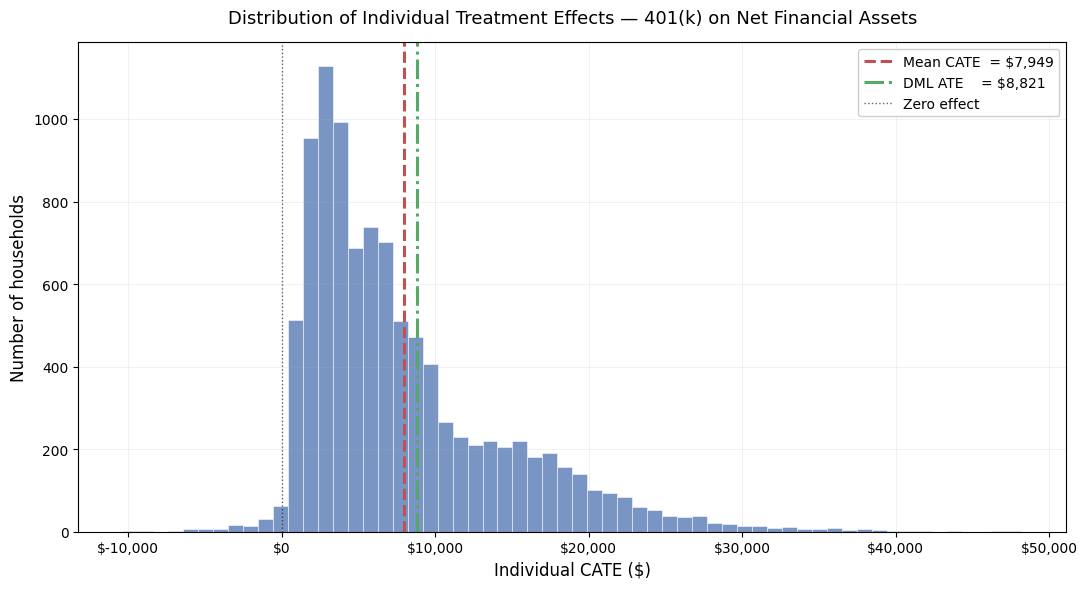

Saved: figures/cate_histogram.png

CATE threshold (75th percentile): $10,766
High-response group: n = 2,479 (25.0%)
Low-response group:  n = 7,436 (75.0%)

=== Subgroup Profiling: High-Response vs Low-Response ===

Covariate         High-Resp       Low-Resp           Diff     % Diff
------------------------------------------------------------------
age                    44.0           40.1            3.9       9.7%
inc                 $65,461        $27,779        $37,682     135.7%
educ                   14.2           12.9            1.3      10.2%
fsize                   3.0            2.8            0.2       8.5%
marr                  0.829          0.530          0.299      56.4%
twoearn               0.629          0.298          0.331     111.2%
db                    0.365          0.240          0.126      52.6%
pira                  0.462          0.169          0.293     173.5%
hown                  0.865          0.559          0.306      54.8%
net_tfa             $44,556 

In [13]:
# -----------------------------------------------------------
# YOUR TASK — Create CATE histogram and identify high-response subgroup
# -----------------------------------------------------------

# Step 1: Plot a histogram of individual CATE estimates
# Include a vertical line at the mean CATE and the DML ATE for comparison

# YOUR CODE HERE
import os
os.makedirs('figures', exist_ok=True)
fig, ax = plt.subplots(figsize=(11, 6))

ax.hist(cate_predictions, bins=60, color='#4C72B0', alpha=0.75,
        edgecolor='white', linewidth=0.5)

# Reference lines
mean_cate = np.mean(cate_predictions)
dml_ate = dml_plr.coef[0]

ax.axvline(mean_cate, color='#C44E52', linestyle='--', linewidth=2.2,
           label=f'Mean CATE  = ${mean_cate:,.0f}')
ax.axvline(dml_ate, color='#55A868', linestyle='-.', linewidth=2.2,
           label=f'DML ATE    = ${dml_ate:,.0f}')
ax.axvline(0, color='black', linestyle=':', linewidth=1, alpha=0.6,
           label='Zero effect')

ax.set_xlabel('Individual CATE ($)', fontsize=12)
ax.set_ylabel('Number of households', fontsize=12)
ax.set_title('Distribution of Individual Treatment Effects — 401(k) on Net Financial Assets',
             fontsize=13, pad=14)
ax.legend(loc='upper right', fontsize=10, framealpha=0.95)
ax.grid(True, alpha=0.25, linestyle='-', linewidth=0.5)
ax.ticklabel_format(style='plain', axis='x')

# Format x-axis with dollar signs and commas
from matplotlib.ticker import FuncFormatter
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.tight_layout()
plt.savefig('figures/cate_histogram.png', dpi=150, bbox_inches='tight')
plt.show()

print('Saved: figures/cate_histogram.png')
print()

# Step 2: Identify the "high-response" subgroup
# Define high-response as individuals with CATE above the 75th percentile
# Compare their characteristics to the rest of the sample

threshold = np.percentile(cate_predictions, 75)

# Create a working DataFrame with CATE attached for profiling
data_with_cate = data.copy()
data_with_cate['cate'] = cate_predictions

high_resp = data_with_cate[data_with_cate['cate'] >= threshold]
low_resp  = data_with_cate[data_with_cate['cate'] <  threshold]

print(f'CATE threshold (75th percentile): ${threshold:,.0f}')
print(f'High-response group: n = {len(high_resp):,} ({len(high_resp)/len(data_with_cate)*100:.1f}%)')
print(f'Low-response group:  n = {len(low_resp):,} ({len(low_resp)/len(data_with_cate)*100:.1f}%)')
print()

# Hint:
# threshold = np.percentile(cate_predictions, 75)
# high_resp = data[cate_predictions >= threshold]
# low_resp = data[cate_predictions < threshold]
# Compare mean income, age, education, etc.

# YOUR CODE HERE

compare_cols = ['age', 'inc', 'educ', 'fsize', 'marr', 'twoearn',
                'db', 'pira', 'hown', 'net_tfa', 'e401']

print('=== Subgroup Profiling: High-Response vs Low-Response ===')
print()

# Means table
means_table = pd.DataFrame({
    'High-Response (top 25%)': high_resp[compare_cols].mean(),
    'Low-Response (bottom 75%)': low_resp[compare_cols].mean(),
})
means_table['Difference'] = means_table['High-Response (top 25%)'] - means_table['Low-Response (bottom 75%)']
means_table['Pct. Diff (%)'] = (means_table['Difference'] / means_table['Low-Response (bottom 75%)'].abs()) * 100

# Pretty-print with appropriate formatting
def _fmt(x, col):
    if col in ['inc', 'net_tfa']:
        return f'${x:,.0f}'
    elif col in ['age', 'educ', 'fsize']:
        return f'{x:.1f}'
    else:
        return f'{x:.3f}'

print(f'{"Covariate":<12} {"High-Resp":>14} {"Low-Resp":>14} {"Diff":>14} {"% Diff":>10}')
print('-' * 66)
for col in compare_cols:
    hi = means_table.loc[col, 'High-Response (top 25%)']
    lo = means_table.loc[col, 'Low-Response (bottom 75%)']
    diff = means_table.loc[col, 'Difference']
    pct = means_table.loc[col, 'Pct. Diff (%)']
    print(f'{col:<12} {_fmt(hi, col):>14} {_fmt(lo, col):>14} {_fmt(diff, col):>14} {pct:>9.1f}%')

print()
print('=== Mean CATE within each group ===')
print(f'High-response mean CATE: ${high_resp["cate"].mean():,.0f}')
print(f'Low-response mean CATE:  ${low_resp["cate"].mean():,.0f}')
print(f'Ratio:                   {high_resp["cate"].mean() / low_resp["cate"].mean():.2f}x')
# VERIFICATION CHECKPOINT
# The high-response subgroup should have systematically different
# characteristics (e.g., higher income, different age profile).
# If all subgroup means are identical, something went wrong.

=== Causal Forest CATE by Income Quartile ===
              Mean CATE  Std CATE  Min CATE  Max CATE     N
inc_quartile                                               
Q1               3352.0    2121.0    -265.0   11243.0  2481
Q2               4188.0    2315.0   -5495.0   14133.0  2477
Q3               7509.0    3558.0  -10317.0   23640.0  2478
Q4              16747.0    6481.0   -8570.0   48190.0  2479

=== Subgroup DML: Separate DML fit per income quartile ===
Fitting 4 separate DML models (this takes ~2 minutes)...
        ATE      SE  CI_low  CI_high       n
Q1   4276.0  1125.0  2071.0   6481.0  2481.0
Q2   3330.0  1217.0   946.0   5715.0  2477.0
Q3   6674.0  1893.0  2964.0  10383.0  2478.0
Q4  16980.0  3719.0  9691.0  24269.0  2479.0

=== Comparison: DML subgroup ATE vs Causal Forest ===
    DML subgroup ATE  CF mean CATE  CF std CATE within     N
Q1            4276.0        3352.0              2121.0  2481
Q2            3330.0        4188.0              2315.0  2477
Q3            

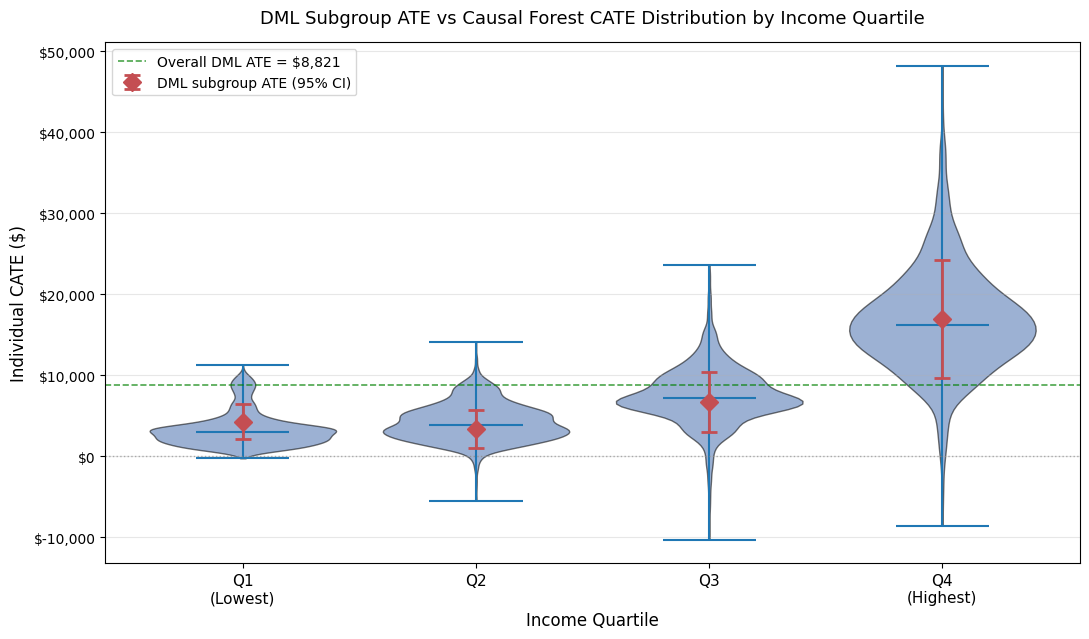


Saved: figures/cf_vs_subgroup_dml.png

Key question: Does the Causal Forest reveal heterogeneity
WITHIN income quartiles that subgroup DML would miss?


In [15]:
# -----------------------------------------------------------
# EXTEND — Compare subgroup DML to Causal Forest CATE
# -----------------------------------------------------------

# The 3916 lab estimated CATE by income quartile using subgroup DML.
# Here we compare that coarse approach to the Causal Forest's
# continuous CATE predictions.

# Step 1: Compute mean Causal Forest CATE by income quartile
data_with_cate = data.copy()
data_with_cate['cate'] = cate_predictions
data_with_cate['inc_quartile'] = pd.qcut(data['inc'], q=4,
                                          labels=['Q1', 'Q2', 'Q3', 'Q4'])

# YOUR CODE: Group cate_predictions by income quartile
# For each quartile, compute mean CATE and std CATE

# YOUR CODE HERE
print('=== Causal Forest CATE by Income Quartile ===')
cf_by_quartile = data_with_cate.groupby('inc_quartile', observed=True)['cate'].agg(
    ['mean', 'std', 'min', 'max', 'count']
).round(0)
cf_by_quartile.columns = ['Mean CATE', 'Std CATE', 'Min CATE', 'Max CATE', 'N']
print(cf_by_quartile)
print()

# Step 2: Within each income quartile, how much variation remains?
# If the within-quartile std is large relative to the between-quartile
# difference, then quartile-level DML misses important heterogeneity.

# YOUR CODE HERE
print('=== Subgroup DML: Separate DML fit per income quartile ===')
print('Fitting 4 separate DML models (this takes ~2 minutes)...')

subgroup_results = {}

for q in ['Q1', 'Q2', 'Q3', 'Q4']:
    subset = data[data_with_cate['inc_quartile'] == q]

    dml_data_q = DoubleMLData(
        subset, y_col=y_col, d_cols=d_col, x_cols=x_cols_clean
    )

    dml_plr_q = DoubleMLPLR(
        dml_data_q,
        ml_l=RandomForestRegressor(n_estimators=200, max_depth=5, random_state=42),
        ml_m=RandomForestRegressor(n_estimators=200, max_depth=5, random_state=42),
        n_folds=5,
        score='partialling out'
    )
    dml_plr_q.fit()

    subgroup_results[q] = {
        'ATE': dml_plr_q.coef[0],
        'SE':  dml_plr_q.se[0],
        'CI_low': dml_plr_q.confint().iloc[0, 0],
        'CI_high': dml_plr_q.confint().iloc[0, 1],
        'n': len(subset),
    }

subgroup_df = pd.DataFrame(subgroup_results).T
print(subgroup_df.round(0))
print()


# Step 3: Visualize — overlay Causal Forest CATE distribution on
# the quartile-level DML bar chart
# Suggestion: Use a violin plot or box plot of CATE by quartile,
# showing the full distribution within each bin

# YOUR CODE HERE
comparison = pd.DataFrame({
    'DML subgroup ATE':    [subgroup_results[q]['ATE'] for q in ['Q1','Q2','Q3','Q4']],
    'CF mean CATE':        cf_by_quartile['Mean CATE'].values,
    'CF std CATE within':  cf_by_quartile['Std CATE'].values,
    'N':                   cf_by_quartile['N'].values,
}, index=['Q1', 'Q2', 'Q3', 'Q4'])
comparison = comparison.round(0)
print('=== Comparison: DML subgroup ATE vs Causal Forest ===')
print(comparison)
print()
between_var = np.var(cf_by_quartile['Mean CATE'].values, ddof=0)
within_var  = np.mean(cf_by_quartile['Std CATE'].values ** 2)

between_sd = np.sqrt(between_var)
within_sd  = np.sqrt(within_var)

print('=== Heterogeneity Decomposition ===')
print(f'Between-quartile SD (explained by income bins): ${between_sd:>10,.0f}')
print(f'Within-quartile  SD (missed by DML subgroup):   ${within_sd:>10,.0f}')
print(f'Ratio within/between:                            {within_sd/between_sd:.2f}x')
print()

if within_sd > between_sd:
    print('FINDING: Within-quartile heterogeneity EXCEEDS between-quartile heterogeneity.')
    print('Implication: Subgroup DML by income quartile MISSES most of the real heterogeneity.')
    print('Causal Forest reveals structure that quartile averaging conceals.')
else:
    print('FINDING: Between-quartile heterogeneity dominates.')
    print('Implication: Income alone captures most of the heterogeneity;')
    print('subgroup DML is approximately sufficient.')

# =======================================================================
# Step 5: Visualization — violin plot of CATE by income quartile
# =======================================================================
fig, ax = plt.subplots(figsize=(11, 6.5))

quartile_data = [data_with_cate[data_with_cate['inc_quartile'] == q]['cate'].values
                 for q in ['Q1', 'Q2', 'Q3', 'Q4']]

parts = ax.violinplot(quartile_data, positions=[1, 2, 3, 4],
                      showmeans=False, showmedians=True, widths=0.8)

for pc in parts['bodies']:
    pc.set_facecolor('#4C72B0')
    pc.set_alpha(0.55)
    pc.set_edgecolor('black')

# Overlay DML subgroup ATE estimates with error bars
subgroup_ates = [subgroup_results[q]['ATE'] for q in ['Q1','Q2','Q3','Q4']]
subgroup_lows = [subgroup_results[q]['CI_low'] for q in ['Q1','Q2','Q3','Q4']]
subgroup_highs = [subgroup_results[q]['CI_high'] for q in ['Q1','Q2','Q3','Q4']]
subgroup_errs = [[ate - lo for ate, lo in zip(subgroup_ates, subgroup_lows)],
                 [hi - ate for ate, hi in zip(subgroup_ates, subgroup_highs)]]

ax.errorbar([1, 2, 3, 4], subgroup_ates, yerr=subgroup_errs,
            fmt='D', color='#C44E52', markersize=9, capsize=6,
            capthick=2, elinewidth=2, label='DML subgroup ATE (95% CI)',
            zorder=5)

ax.axhline(0, color='gray', linestyle=':', linewidth=1, alpha=0.6)
ax.axhline(dml_plr.coef[0], color='green', linestyle='--', linewidth=1.2,
           alpha=0.7, label=f'Overall DML ATE = ${dml_plr.coef[0]:,.0f}')

ax.set_xticks([1, 2, 3, 4])
ax.set_xticklabels(['Q1\n(Lowest)', 'Q2', 'Q3', 'Q4\n(Highest)'], fontsize=11)
ax.set_xlabel('Income Quartile', fontsize=12)
ax.set_ylabel('Individual CATE ($)', fontsize=12)
ax.set_title('DML Subgroup ATE vs Causal Forest CATE Distribution by Income Quartile',
             fontsize=13, pad=14)
ax.legend(loc='upper left', fontsize=10)
ax.grid(True, alpha=0.3, axis='y')

from matplotlib.ticker import FuncFormatter
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.tight_layout()
plt.savefig('figures/cf_vs_subgroup_dml.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nSaved: figures/cf_vs_subgroup_dml.png')
print()
print('Key question: Does the Causal Forest reveal heterogeneity')
print('WITHIN income quartiles that subgroup DML would miss?')


---

## Reflection

Answer in 3-5 sentences:

**When would you choose DML for ATE estimation vs. Causal Forests for CATE estimation?**

Consider:
- What is your research question? (average policy effect vs. targeting)
- How much data do you have? (CATE requires more observations per subgroup)
- How interpretable do the results need to be? (ATE is a single number; CATE is a distribution)
- What are the credibility concerns? (ATE with sensitivity analysis vs. CATE with wider CIs)

*Your answer:*

---

## Digital Portfolio: Institutional Signaling

### Generate Your Professional README

Copy and paste the prompt below into Claude or ChatGPT. **Do NOT ask the AI to write Python code — only documentation.**

```text
"I need help writing a project description for my data science lab.
**Important Rule:** Do NOT generate any Python code for me.

**What I did in this lab:**
* Diagnosed and fixed a broken manual DML implementation (3 bugs:
  data leakage in cross-fitting, missing treatment residualization,
  wrong IV-formula for theta)
* Verified the fix recovers the true ATE (=5.0) on a simulated DGP
* Estimated the ATE of 401(k) eligibility on net financial assets
  using DoubleML with Random Forest nuisance learners and 5-fold cross-fitting
* Ran sensitivity analysis to assess robustness to unmeasured confounders
* Fit a CausalForestDML (EconML) to estimate individual-level CATEs
* Compared subgroup DML (quartile-level) to Causal Forest (individual-level)
  heterogeneity detection
* Key finding: [FILL IN — ATE, robustness, which method reveals finer heterogeneity?]

**Please write a README.md entry including:**
1. Project Title: Causal ML — DML and Causal Forests for Policy Evaluation
2. Objective: A professional one-sentence summary
3. Methodology: Bullet points of technical steps
4. Key Findings: Summary of results
Make this sound like a professional tech economist wrote it."
```

### Push to GitHub

```bash
cd econ-lab-24-causal-ml
git add notebooks/ figures/ README.md
git commit -m "Lab 24: Causal ML — DML & Causal Forests for 401(k) Policy"
git push origin main
```

Submit your GitHub repo link on Canvas.

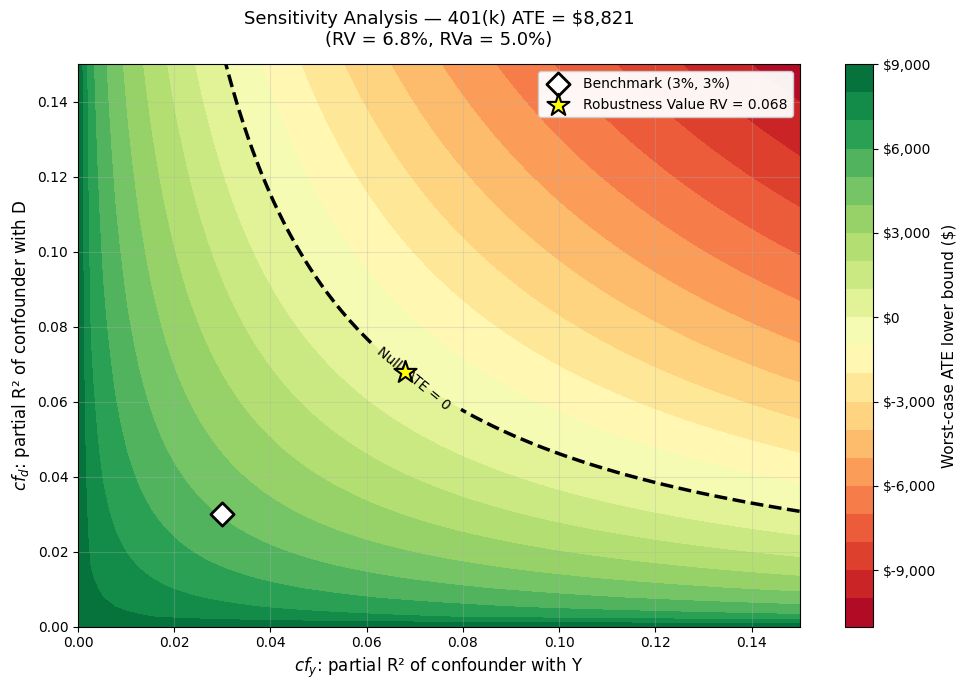

Saved: figures/sensitivity_plot.png


In [16]:
# -----------------------------------------------------------
# Manual sensitivity plot via matplotlib (fallback)
# -----------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

theta_hat = dml_plr.coef[0]
se_hat = dml_plr.se[0]
rv = dml_plr.sensitivity_params['rv'][0]
rv_a = dml_plr.sensitivity_params['rva'][0]

# Build a contour grid of worst-case theta lower bound
# over (cf_y, cf_d) for display purposes
cf_grid = np.linspace(0, 0.15, 60)
CF_Y, CF_D = np.meshgrid(cf_grid, cf_grid)

# Simple approximation: worst-case bias scales with sqrt(cf_y * cf_d)
# This mirrors the Cinelli-Hazlett bound structure
bias_factor = np.sqrt(CF_Y * CF_D)
# Scale to match observed RV threshold at theta = 0
# rv is the value where bias_factor = bias_needed_to_nullify
bias_needed = rv  # partial R^2 where lower bound hits 0
theta_lower = theta_hat * (1 - bias_factor / bias_needed)
theta_lower = np.clip(theta_lower, a_min=None, a_max=theta_hat)

fig, ax = plt.subplots(figsize=(10, 7))

# Filled contour of worst-case theta
cs = ax.contourf(CF_Y, CF_D, theta_lower, levels=20, cmap='RdYlGn')
cbar = plt.colorbar(cs, ax=ax)
cbar.set_label('Worst-case ATE lower bound ($)', fontsize=11)
cbar.ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'${x:,.0f}'))

# Zero contour (critical threshold — where estimate is nullified)
cs_zero = ax.contour(CF_Y, CF_D, theta_lower, levels=[0],
                      colors='black', linewidths=2.5, linestyles='--')
ax.clabel(cs_zero, inline=True, fontsize=10, fmt='Null: ATE = 0')

# Benchmark point (cf_y = cf_d = 0.03)
ax.scatter([0.03], [0.03], marker='D', color='white', edgecolors='black',
           s=140, zorder=5, linewidths=2, label='Benchmark (3%, 3%)')
ax.scatter([rv], [rv], marker='*', color='yellow', edgecolors='black',
           s=280, zorder=5, linewidths=1.5,
           label=f'Robustness Value RV = {rv:.3f}')

ax.set_xlabel('$cf_y$: partial R² of confounder with Y', fontsize=12)
ax.set_ylabel('$cf_d$: partial R² of confounder with D', fontsize=12)
ax.set_title(f'Sensitivity Analysis — 401(k) ATE = ${theta_hat:,.0f}\n'
             f'(RV = {rv*100:.1f}%, RVa = {rv_a*100:.1f}%)',
             fontsize=13, pad=14)
ax.legend(loc='upper right', fontsize=10, framealpha=0.95)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 0.15)
ax.set_ylim(0, 0.15)

plt.tight_layout()
plt.savefig('figures/sensitivity_plot.png', dpi=150, bbox_inches='tight')
plt.show()

print('Saved: figures/sensitivity_plot.png')